# 04 - Modelo Temporal Leve (Trilha B) + Ablacoes de Balanceamento/Ordinalidade

Objetivo: treinar um modelo sequencial leve (BiLSTM / 1D-CNN) sobre a sequencia de features por frame (EAR, MAR, yaw, pitch, roll) extraida no Notebook 02, testando:

1. Perda padrao (cross-entropy) com `class weights`.
2. Perda **focal** (foco nas classes raras).
3. Formulacao **ordinal** (CORAL) vs. nominal padrao.
4. **Early stopping** monitorando macro-F1 de validacao (nao a loss).

Cenario assumido: **CPU-only** (ver Secao 1 e 7 do plano). Ha uma secao opcional ao final para fine-tuning de um backbone CNN leve, caso haja GPU disponivel (Colab/Kaggle).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, cohen_kappa_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

ROOT = Path.cwd().parent
FEATURES_DIR = ROOT / "datasets" / "DAiSEE" / "features"
TARGET = "Engagement"
SEQ_LEN = 20  # deve bater com N_FRAMES_PER_CLIP do Notebook 02
FEAT_COLS = ["ear", "mar", "yaw", "pitch", "roll", "face_detected"]

Device: cuda


In [2]:
def build_sequences(split_name, scaler=None, fit_scaler=False):
    df = pd.read_parquet(FEATURES_DIR / f"{split_name}_frame_features.parquet")
    df["face_detected"] = df["face_detected"].astype(float)
    # Mesma correcao de descontinuidade circular do roll aplicada no Notebook 03:
    # os valores concentram-se junto de +-180, entao [0,360) os torna continuos.
    df["roll"] = df["roll"] % 360
    for c in ["ear", "mar", "yaw", "pitch", "roll"]:
        df[c] = df[c].fillna(0.0)

    if fit_scaler or scaler is None:
        scaler = StandardScaler().fit(df[FEAT_COLS])
    df[FEAT_COLS] = scaler.transform(df[FEAT_COLS])

    sequences, labels, clip_ids = [], [], []
    for clip_id, g in df.groupby("ClipID"):
        g = g.sort_values("frame_idx")
        seq = g[FEAT_COLS].values
        if len(seq) < SEQ_LEN:
            pad = np.zeros((SEQ_LEN - len(seq), len(FEAT_COLS)))
            seq = np.vstack([seq, pad])
        else:
            seq = seq[:SEQ_LEN]
        sequences.append(seq)
        labels.append(g[TARGET].iloc[0])
        clip_ids.append(clip_id)

    return np.array(sequences, dtype=np.float32), np.array(labels, dtype=np.int64), clip_ids, scaler

In [3]:
X_train, y_train, _, scaler = build_sequences("train", fit_scaler=True)
X_val, y_val, _, _ = build_sequences("validation", scaler=scaler)
X_test, y_test, _, _ = build_sequences("test", scaler=scaler)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

class ClipSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(ClipSequenceDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(ClipSequenceDataset(X_val, y_val), batch_size=64)
test_loader = DataLoader(ClipSequenceDataset(X_test, y_test), batch_size=64)

Shapes: (4851, 20, 6) (1429, 20, 6) (1638, 20, 6)


## Modelo: BiLSTM leve

In [4]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, n_features, hidden_size=32, n_classes=4):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, batch_first=True, bidirectional=True, num_layers=1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size * 2, n_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out.mean(dim=1)  # pooling temporal simples
        out = self.dropout(out)
        return self.fc(out)

## Perda focal (foco em classes raras) e pesos de classe

In [5]:
class FocalLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        self.class_weights = class_weights

    def forward(self, logits, target):
        ce = nn.functional.cross_entropy(logits, target, weight=self.class_weights, reduction="none")
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

class_counts = np.bincount(y_train, minlength=4)
class_weights = torch.tensor((1.0 / (class_counts + 1e-6)) * class_counts.sum() / 4, dtype=torch.float32).to(DEVICE)
print("Pesos de classe:", class_weights)

Pesos de classe: tensor([36.7500,  6.0336,  0.4902,  0.5659], device='cuda:0')


## Loop de treino com early stopping (monitorando macro-F1 de validacao)

In [6]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
    return np.array(all_labels), np.array(all_preds)

def train_model(model, loss_fn, train_loader, val_loader, max_epochs=50, patience=7, lr=1e-3):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_f1, best_state, epochs_no_improve = -1, None, 0
    history = []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)

        y_true_val, y_pred_val = evaluate(model, val_loader)
        val_f1 = f1_score(y_true_val, y_pred_val, average="macro")
        history.append({"epoch": epoch, "train_loss": epoch_loss / len(train_loader.dataset), "val_macro_f1": val_f1})
        print(f"Epoch {epoch:02d} | loss={history[-1]['train_loss']:.4f} | val_macro_f1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1, best_state, epochs_no_improve = val_f1, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping na epoca {epoch} (sem melhora ha {patience} epocas)")
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

Epoch 00 | loss=0.8443 | val_macro_f1=0.0681


Epoch 01 | loss=0.7843 | val_macro_f1=0.0746


Epoch 02 | loss=0.7440 | val_macro_f1=0.0841


Epoch 03 | loss=0.7286 | val_macro_f1=0.0939


Epoch 04 | loss=0.7170 | val_macro_f1=0.1289


...

Epoch 07 | loss=0.6922 | val_macro_f1=0.0880


Epoch 08 | loss=0.6806 | val_macro_f1=0.0795


Epoch 09 | loss=0.6621 | val_macro_f1=0.1186


Epoch 10 | loss=0.6516 | val_macro_f1=0.1159


Epoch 11 | loss=0.6408 | val_macro_f1=0.1123
Early stopping na epoca 11 (sem melhora ha 7 epocas)


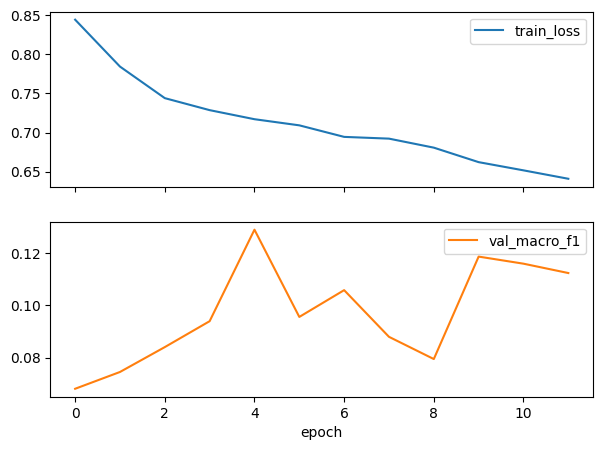

In [7]:
n_features = X_train.shape[2]
model = BiLSTMClassifier(n_features=n_features)
loss_fn = FocalLoss(class_weights=class_weights, gamma=2.0)

model, history = train_model(model, loss_fn, train_loader, val_loader)

history.plot(x="epoch", y=["train_loss", "val_macro_f1"], subplots=True, figsize=(7, 5))
plt.show()

In [8]:
y_true_test, y_pred_test = evaluate(model, test_loader)
print("Acuracia:", accuracy_score(y_true_test, y_pred_test))
print("Macro-F1:", f1_score(y_true_test, y_pred_test, average="macro"))
print("Kappa:", cohen_kappa_score(y_true_test, y_pred_test))
print(confusion_matrix(y_true_test, y_pred_test))

dl_results = {
    "modelo": "BiLSTM + Focal Loss (class-weighted)",
    "acc": accuracy_score(y_true_test, y_pred_test),
    "macro_f1": f1_score(y_true_test, y_pred_test, average="macro"),
    "kappa": cohen_kappa_score(y_true_test, y_pred_test),
}
pd.DataFrame([dl_results]).to_csv(FEATURES_DIR / "resultados_trilha_b_dl.csv", index=False)

# Probabilidades no teste (softmax), para bootstrap/ROC binaria no Notebook 05
model.eval()
probs = []
with torch.no_grad():
    for xb, _ in test_loader:
        probs.append(torch.softmax(model(xb.to(DEVICE)), dim=1).cpu().numpy())
probs = np.vstack(probs)

pred_dl = pd.DataFrame({"y_true": y_true_test, "y_pred": y_pred_test})
for k in range(probs.shape[1]):
    pred_dl[f"proba_{k}"] = probs[:, k]
pred_dl.to_csv(FEATURES_DIR / "predicoes_teste_trilha_b.csv", index=False)

dl_results

Acuracia: 0.1568986568986569
Macro-F1: 0.12101001908035319
Kappa: 0.032611665993110384
[[  1   2   0   1]
 [ 15  51   0  15]
 [115 591   2 141]
 [ 58 442   1 203]]


{'modelo': 'BiLSTM + Focal Loss (class-weighted)',
 'acc': 0.1568986568986569,
 'macro_f1': 0.12101001908035319,
 'kappa': 0.032611665993110384}

## Variante ordinal (CORAL) - comparar ganho em kappa vs. classificacao nominal

CORAL (Cao et al.) transforma a classificacao ordinal de K classes em K-1 problemas binarios acumulados ("P(y > k)"), preservando a ordem 0<1<2<3. Referencia conceitual: Abedi & Khan (2021, 2024) - ver Secao 3 do plano.

In [9]:
N_CLASSES = 4

def to_coral_targets(y, n_classes=N_CLASSES):
    # y -> matriz binaria [n_classes-1] indicando se y > k, para k=0..n_classes-2
    levels = torch.zeros((len(y), n_classes - 1), device=y.device)
    for i, yi in enumerate(y):
        levels[i, : int(yi)] = 1.0
    return levels

class CoralBiLSTM(nn.Module):
    def __init__(self, n_features, hidden_size=32, n_classes=N_CLASSES):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size * 2, 1, bias=False)
        self.bias = nn.Parameter(torch.zeros(n_classes - 1))

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out.mean(dim=1))
        logit = self.fc(out)
        return logit + self.bias

# Pesos por limiar k (importancia das transicoes raras 0|1 e 1|2)
coral_level_weights = torch.tensor(
    [(y_train > k).mean() * (1 - (y_train > k).mean()) for k in range(N_CLASSES - 1)],
    dtype=torch.float32, device=DEVICE
)
coral_level_weights = (1.0 / (coral_level_weights + 1e-6))
coral_level_weights = coral_level_weights / coral_level_weights.mean()
print("Pesos por limiar CORAL:", coral_level_weights)

def coral_loss(logits, targets):
    return nn.functional.binary_cross_entropy_with_logits(
        logits, targets, weight=coral_level_weights.expand_as(targets)
    )

def coral_predict(logits):
    return (torch.sigmoid(logits) > 0.5).sum(dim=1)

def train_coral(model, train_loader, val_loader, max_epochs=50, patience=7, lr=1e-3):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_f1, best_state, epochs_no_improve = -1, None, 0
    history = []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = coral_loss(logits, to_coral_targets(yb))
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)

        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                preds.extend(coral_predict(model(xb.to(DEVICE))).cpu().numpy())
                trues.extend(yb.numpy())
        val_f1 = f1_score(trues, preds, average="macro")
        history.append({"epoch": epoch, "train_loss": epoch_loss / len(train_loader.dataset), "val_macro_f1": val_f1})
        print(f"[CORAL] Epoch {epoch:02d} | loss={history[-1]['train_loss']:.4f} | val_macro_f1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1, best_state, epochs_no_improve = val_f1, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[CORAL] Early stopping na epoca {epoch}")
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

coral_model, coral_history = train_coral(CoralBiLSTM(n_features=n_features), train_loader, val_loader)

# Avaliacao no teste
coral_model.eval()
coral_preds, coral_trues = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        coral_preds.extend(coral_predict(coral_model(xb.to(DEVICE))).cpu().numpy())
        coral_trues.extend(yb.numpy())
coral_preds, coral_trues = np.array(coral_preds), np.array(coral_trues)

coral_results = {
    "modelo": "BiLSTM ordinal (CORAL)",
    "acc": accuracy_score(coral_trues, coral_preds),
    "macro_f1": f1_score(coral_trues, coral_preds, average="macro"),
    "kappa": cohen_kappa_score(coral_trues, coral_preds),
}
print("\nCORAL:", coral_results)
print("Ganho em kappa vs. nominal (focal):", round(coral_results["kappa"] - dl_results["kappa"], 4))
print(confusion_matrix(coral_trues, coral_preds))

pd.DataFrame([dl_results, coral_results]).to_csv(FEATURES_DIR / "resultados_trilha_b_dl.csv", index=False)

Pesos por limiar CORAL: tensor([2.5541, 0.3759, 0.0700], device='cuda:0')


[CORAL] Epoch 00 | loss=0.2436 | val_macro_f1=0.1197


[CORAL] Epoch 01 | loss=0.1087 | val_macro_f1=0.1197


[CORAL] Epoch 02 | loss=0.1055 | val_macro_f1=0.1247


[CORAL] Epoch 03 | loss=0.1021 | val_macro_f1=0.1348


...

[CORAL] Epoch 41 | loss=0.0564 | val_macro_f1=0.2759


[CORAL] Epoch 42 | loss=0.0567 | val_macro_f1=0.2916


[CORAL] Epoch 43 | loss=0.0567 | val_macro_f1=0.2920


[CORAL] Epoch 44 | loss=0.0568 | val_macro_f1=0.2862


[CORAL] Epoch 45 | loss=0.0564 | val_macro_f1=0.2905
[CORAL] Early stopping na epoca 45

CORAL: {'modelo': 'BiLSTM ordinal (CORAL)', 'acc': 0.5238095238095238, 'macro_f1': 0.2657771090971844, 'kappa': 0.06061131877924453}
Ganho em kappa vs. nominal (focal): 0.028
[[  0   0   4   0]
 [  2   3  64  12]
 [  1   4 652 192]
 [  0   1 500 203]]


## [Opcional / stretch goal] Fine-tuning de CNN leve (requer GPU)

Se houver GPU disponivel (Colab/Kaggle), uma extensao natural e substituir as features tabulares por embeddings de um backbone pre-treinado leve (ex.: `timm.create_model('mobilenetv3_small_100', pretrained=True)` ou `efficientnet_b0`), extraindo o embedding do rosto recortado em cada frame amostrado e alimentando o mesmo `BiLSTMClassifier` acima. Isso aproxima a abordagem do ViBED-Net (arXiv:2510.18016, ver Secao 3 do plano), mas com custo de treino maior - tratar como extensao, nao como bloqueador do prazo de 2 dias.

## Checklist de saida
- [ ] Modelo BiLSTM + focal loss treinado com early stopping monitorando macro-F1
- [ ] Metricas completas (acc, macro-F1, kappa, matriz de confusao) no teste
- [ ] `resultados_trilha_b_dl.csv` salvo para consolidacao
- [ ] Variante ordinal (CORAL) implementada/comparada (ou justificativa se nao houve tempo)

Proximo passo: `05_avaliacao_comparativa.ipynb`.